In [1]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
#importing all the libraries and functions we need for thuiis use case 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics


In [5]:
#importing the house price data 
house_price_dataset = sklearn.datasets.fetch_california_housing()

In [6]:
print(house_price_dataset)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [10]:
#loading all the data to a panda dataframe
house_price_df = pd.DataFrame(house_price_dataset.data , columns = house_price_dataset.feature_names)

In [12]:
house_price_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [14]:
#add the target column to the dataframe\
house_price_df['Price'] = house_price_dataset.target

In [15]:
house_price_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
#checking the no of rows and cols in the DF
house_price_df.shape

(20640, 9)

In [19]:
#Check for missing values
house_price_df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [20]:
#stastistical measures of the dataset
house_price_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [21]:
#Understanding the corelation between various features in the dataset
#Finding Corelation between the data 
corelation = house_price_df.corr()

<Axes: >

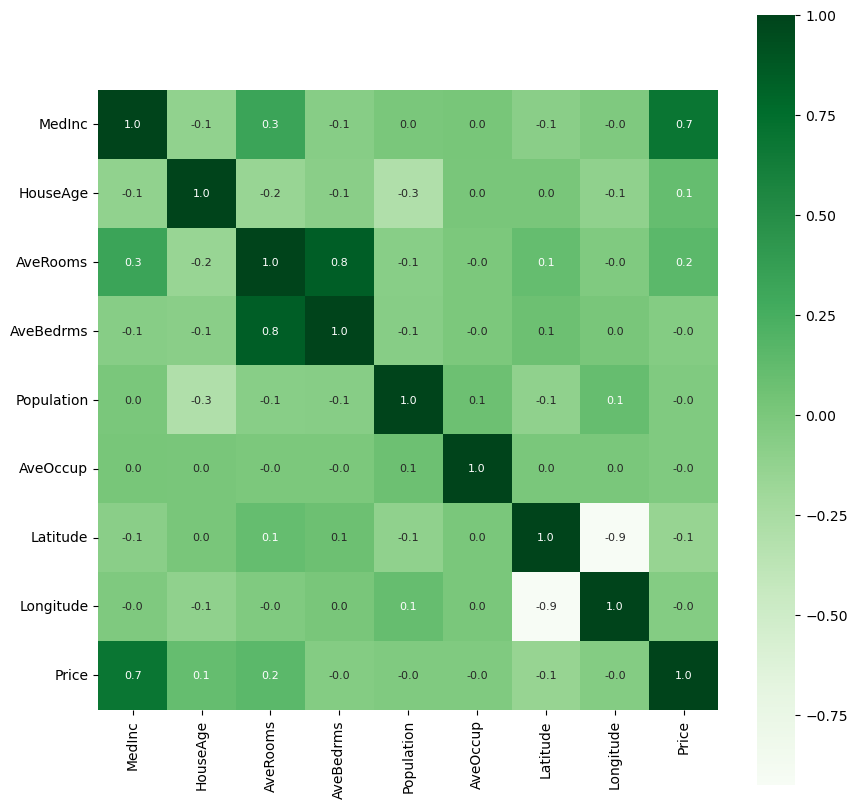

In [28]:
#constructing the heapmap to understand the corelation
plt.figure(figsize = (10,10))
sns.heatmap(corelation,cbar = True , square = True , fmt = '.1f' , annot = True ,annot_kws = {'size':8} , cmap = 'Greens')

In [32]:
#Splitting The Data and The Targets
x = house_price_df.drop(['Price'] , axis = 1)
y = house_price_df['Price']

In [33]:
#printing Data and Targets
print(x)
print(y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

In [34]:
#split the data into train and test data
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 ,random_state = 2)

In [35]:
print(x.shape,x_train.shape,x_test.shape)

(20640, 8) (16512, 8) (4128, 8)


In [36]:
#Model Training We are using XGBoost Regression Model      Decision tree based model hands_on Training Model 
#Loading The Model
model = XGBRegressor()

In [37]:
model.fit(x_train , y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [38]:
#Now Evaluation Step
#Prediction on Training Data
#accuracy for prediction on Training Data
training_data_prediction = model.predict(x_train)

In [39]:
print(training_data_prediction)

[0.5523039 3.0850039 0.5835302 ... 1.9204227 1.952873  0.6768683]


In [42]:
#R squared error
score_1 = metrics.r2_score(y_train,training_data_prediction)

#Mean - Absolute Error 
score_2 = metrics.mean_absolute_error(y_train , training_data_prediction) 
print('R squared error for Trained Data : ' , score_1)
print('Mean Absolute error for Trained Data : ' , score_2)

R squared error for Trained Data :  0.943650140819218
Mean Absolute error for Trained Data :  0.19336487006121048


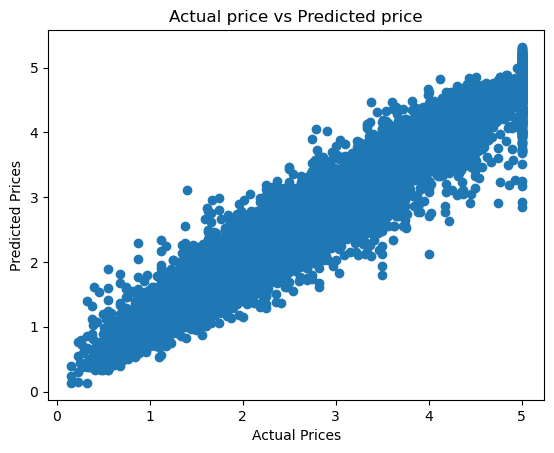

In [47]:
#Visualizing the actual Prices and the Predicted Prices
plt.scatter(y_train , training_data_prediction)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual price vs Predicted price')
plt.show()

In [43]:
#Prediction on Test Data
test_data_prediction = model.predict(x_test)

In [44]:
print(test_data_prediction)

[2.8649795  1.790346   0.92074925 ... 1.5385513  0.92647874 2.043316  ]


In [45]:
#R squared error
score_1 = metrics.r2_score(y_test,test_data_prediction)

#Mean - Absolute Error 
score_2 = metrics.mean_absolute_error(y_test , test_data_prediction) 
print('R squared error for Test Data : ' , score_1)
print('Mean Absolute error for Test Data : ' , score_2)

R squared error for Test Data :  0.8338000331788725
Mean Absolute error for Test Data :  0.3108631800268186


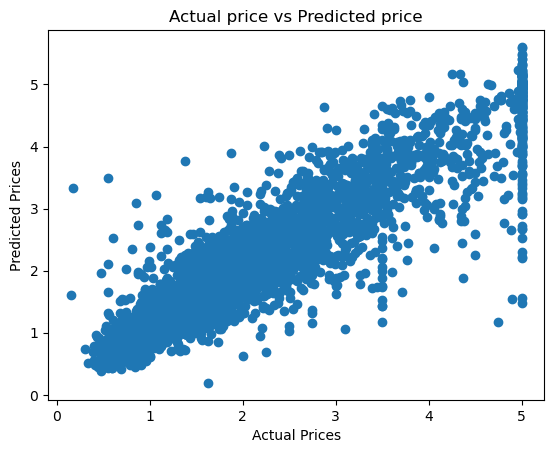

In [48]:
#Visualizing the actual Prices and the Predicted Prices
plt.scatter(y_test , test_data_prediction)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual price vs Predicted price')
plt.show()